In [3]:
import gempy as gp
import gemgis as gg
import numpy as np
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/Users/amjonz/Documents/GitHub/gempydefaulting/')
import DEV_gempydefaulting_03 as gdef


In [4]:
def return_surface_from_geomodel(geo_model, surface=None):

    """
    Gather vertices and faces to create polydata set
    input:  gempy - (geo_model) computed gempy geomodel for extraction
            surface - (int) address of surface to mesh

    
    this is a temporary functions as this is working in gemgis v1.2  "create_depth_map_from gempy" or something like that
    
    """
# collect vertices
    vertices = geo_model.input_transform.apply_inverse(geo_model.solutions.raw_arrays.vertices[surface])
# collect faces
    faces = np.hstack(np.pad(geo_model.solutions.raw_arrays.edges[surface], ((0, 0), (1, 0)), 'constant', constant_values=3))
 
# combine into Polydata Mesh
    mesh = pv.PolyData(vertices, faces)

# Build scaler for the mesh
    mesh['Depth [m]'] = mesh.points[:, 2]

    return mesh

In [5]:
import numpy as np

from gempy.core.data.structural_element import StructuralElement
from gempy_engine.core.data.transforms import Transform
from gempy_viewer.modules.plot_3d.vista import GemPyToVista
#from ...optional_dependencies import require_pyvista


def plot_surfaces(
        gempy_vista: GemPyToVista,
        structural_elements_with_solution: list[StructuralElement],
        input_transform: Transform = None,
        grid_transform: Transform = None,
        **kwargs
):
    # ? Probably would be better to do the transformation somewhere else. But we leave it like this for now
    pv = require_pyvista()
    # ! If the order of the meshes does not match the order of scalar_field_at_surface points we need to reorder them in 'multi_scalar_dual_contouring.py'
    
    topography_mesh = gempy_vista.surface_poly.get('topography', None)
    
    for element in structural_elements_with_solution:
        vertices_ = element.vertices
        edges_ = element.edges
        if vertices_ is None or vertices_.shape[0] == 0 or edges_.shape[0] == 0:
            continue

        if grid_transform is not None:
            vertices_ = grid_transform.apply_with_cached_pivot(vertices_)
        if input_transform is not None:
            vertices_ = input_transform.apply(vertices_)
        surf = pv.PolyData(vertices_, np.insert(edges_, 0, 3, axis=1).ravel())
        
        if topography_mesh is not None:
            surf = surf.clip_surface(topography_mesh, invert=True)
        
        gempy_vista.surface_poly[element.name] = surf
        gempy_vista.surface_actors[element.name] = gempy_vista.p.add_mesh(
            surf,
            pv.Color(element.color).float_rgb,
            show_scalar_bar=False,
            **kwargs
        )

Surface points hash:  8fe9250462c3e65080818a84d29925378664f6be46301dcdb42ed4047aa3fe6f
Orientations hash:  58d1d28be0c52dfdcedf36c9adc3b231e67d6923554159d6484dba589b0bfc5e
Setting Backend To: AvailableBackends.numpy


/opt/anaconda3/envs/gp/lib/python3.12/site-packages/gempy_viewer/API/_plot_2d_API.py:174: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Widget(value='<iframe src="http://localhost:60372/index.html?ui=P_0x2ce44c710_18&reconnect=auto" class="pyvist…

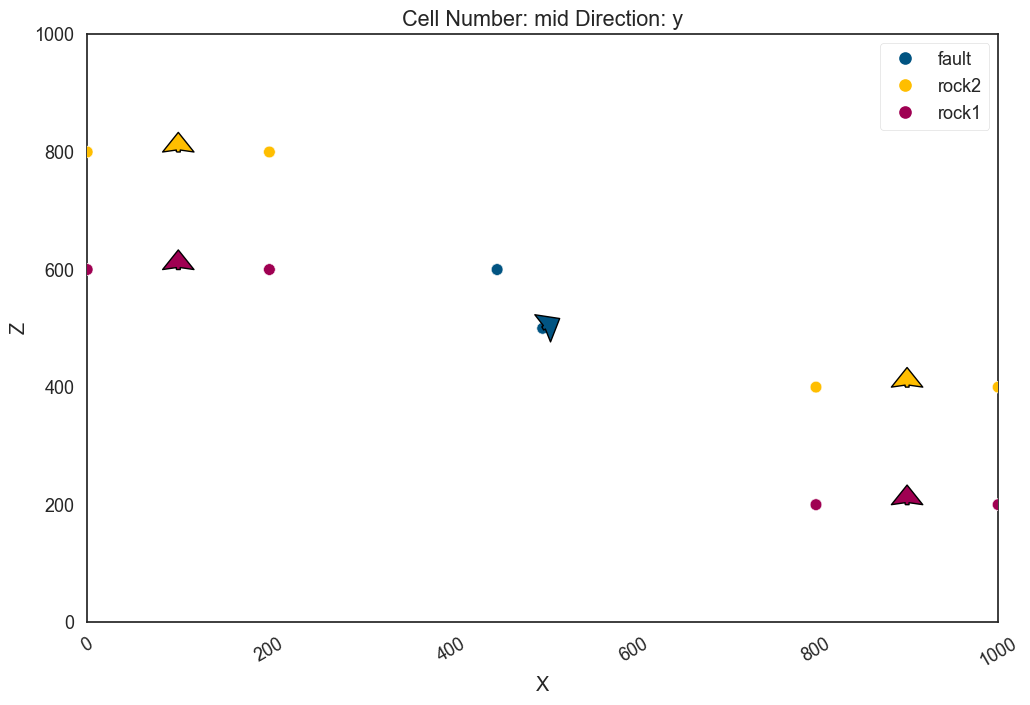

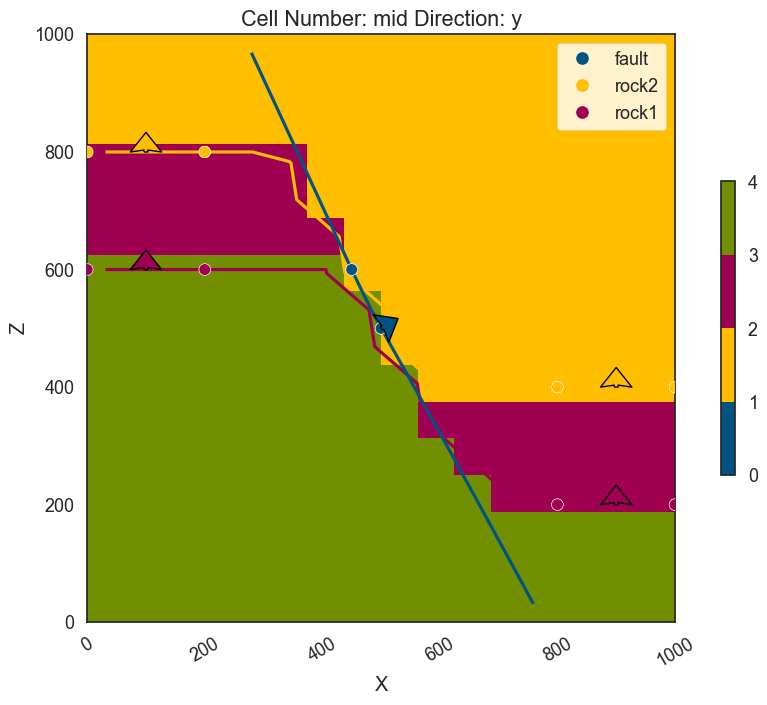

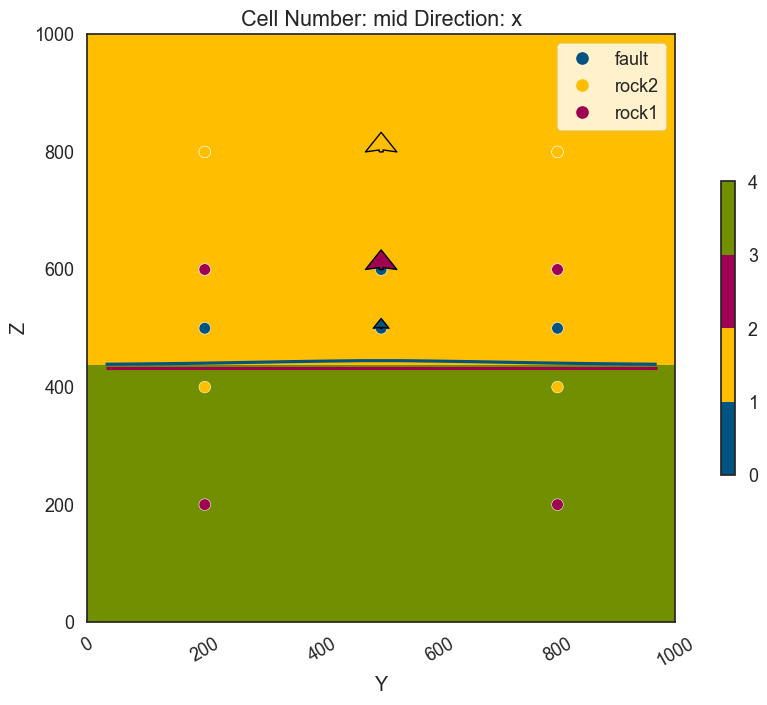

In [26]:
"""
Model 5 - Fault
===============

This script demonstrates how to create a simple fault model with constant offset using GemPy,
a Python-based, open-source library for implicit geological modeling.
"""

# Import necessary libraries
import gempy as gp
import gempy_viewer as gpv
import numpy as np
from gempy_engine.core.data.stack_relation_type import StackRelationType

# sphinx_gallery_thumbnail_number = 2


# %%
# Generate the model
# Define the path to data
data_path = 'https://raw.githubusercontent.com/cgre-aachen/gempy_data/master/'
path_to_data = data_path + "/data/input_data/jan_models/"
# Create a GeoModel instance
data = gp.create_geomodel(
    project_name='fault',
    extent=[0, 1000, 0, 1000, 0, 1000],
    refinement=4,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=path_to_data + "model5_orientations.csv",
        path_to_surface_points=path_to_data + "model5_surface_points.csv"
    )
)
# Map geological series to surfaces
gp.map_stack_to_surfaces(
    gempy_model=data,
    mapping_object={
        "Fault_Series": 'fault',
        "Strat_Series": ('rock2', 'rock1')
    }
)
# Define fault groups
data.structural_frame.structural_groups[0].structural_relation = StackRelationType.FAULT
data.structural_frame.fault_relations = np.array([[0, 1], [0, 0]])
# Compute the geological model
gp.compute_model(data)
geo_data = data

# %%
# Plot the initial geological model in the y direction
gpv.plot_2d(geo_data, direction=['y'], show_results=False)

# %%

# Plot the result of the model in the x and y direction with data
gpv.plot_2d(geo_data, direction='y', show_data=True)
gpv.plot_2d(geo_data, direction='x', show_data=True)

gpv.plot_3d(geo_data, show_data=True, show_boundaries=True, show_lith=False, kwargs_plotter={'notebook' : True},)

In [24]:
gdef.gempydefaulting(geo_data, 130, 11)

faults [0]   surfaces  [1, 2]
**********0************
**********0************
fault Norm [0.76 0.   0.39]
Fault normal >= 0
left_edges  average normal [ 0.03 -0.   -1.  ]
Left 0 scalar dir =[-246.33   -0.   -144.08]
Right edges avg Norm [ 0. -0. -1.]
Right 0 scalar dir =[226.15   0.   145.09]
**********1************
**********0************
fault Norm [0.76 0.   0.39]
Fault normal >= 0
left_edges  average normal [ 0. -0. -1.]
Left 1 scalar dir =[-226.15   -0.   -145.09]
Right edges avg Norm [ 0.01  0.   -1.  ]
Right 1 scalar dir =[232.12   0.   144.85]


/opt/anaconda3/envs/gp/lib/python3.12/site-packages/pyvista/core/filters/poly_data.py:2942: PyVistaFutureWarning: The default value of the ``capping`` keyword argument will change in a future version to ``True`` to match the behavior of VTK. We recommend passing the keyword explicitly to prevent future surprises.
  warnings.warn(


Widget(value='<iframe src="http://localhost:60372/index.html?ui=P_0x29e7c09e0_17&reconnect=auto" class="pyvist…

In [25]:
type(geo_data)

gempy.core.data.geo_model.GeoModel